EDA


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px


In [4]:
base_path = r"C:\Users\ariel\Documents\Kurs Data Science\projekty\Projekt Grupowy - Predykcja popytu na produkty\jdszr23-grupa-3\projekt_grupowy\dane"

In [5]:
orders = pd.read_csv(f"{base_path}\\olist_orders_dataset.csv")
order_items = pd.read_csv(f"{base_path}\\olist_order_items_dataset.csv")
products = pd.read_csv(f"{base_path}\\olist_products_dataset.csv")
category_translation = pd.read_csv(f"{base_path}\\product_category_name_translation.csv")

In [6]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [9]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [10]:
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("products:", products.shape)
print("category_translation:", category_translation.shape)

orders: (99441, 8)
order_items: (112650, 7)
products: (32951, 9)
category_translation: (71, 2)


In [11]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [12]:
order_items.dtypes

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

In [13]:
products.dtypes

product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

In [14]:
category_translation.dtypes

product_category_name            object
product_category_name_english    object
dtype: object

In [15]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [16]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [17]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [18]:
category_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [19]:
orders.duplicated().sum()

np.int64(0)

In [20]:
order_items.duplicated().sum()

np.int64(0)

In [21]:
products.duplicated().sum()

np.int64(0)

In [22]:
category_translation.duplicated().sum()

np.int64(0)

In [23]:
orders["order_id"].nunique(), len(orders)

(99441, 99441)

In [24]:
products["product_id"].nunique(), len(products)

(32951, 32951)

In [25]:
category_translation["product_category_name"].nunique(), len(category_translation)

(71, 71)

In [26]:
sales_base = order_items.merge(
    orders,
    on="order_id",
    how="left"
)

In [27]:
sales_base.shape

(112650, 14)

In [28]:
order_items.shape[0], sales_base.shape[0]

(112650, 112650)

In [29]:
sales_base = sales_base.merge(
    products,
    on="product_id",
    how="left"
)

In [30]:
sales_base = sales_base.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [31]:
sales_base.shape

(112650, 23)

In [32]:
sales_base.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,order_estimated_delivery_date,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-29 00:00:00,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-15 00:00:00,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-02-05 00:00:00,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-20 00:00:00,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-03-17 00:00:00,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [33]:
sales_base.isnull().sum().sort_values(ascending=False).head(20)

order_delivered_customer_date    2454
product_category_name_english    1627
product_photos_qty               1603
product_description_lenght       1603
product_name_lenght              1603
product_category_name            1603
order_delivered_carrier_date     1194
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
order_approved_at                  15
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_item_id                       0
freight_value                       0
order_estimated_delivery_date       0
price                               0
shipping_limit_date                 0
dtype: int64

In [34]:
sales_base.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english']

In [35]:
sales_base["order_status"].value_counts(dropna=False)

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

In [36]:
df = sales_base.copy()

In [37]:
df.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english']

In [38]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [39]:
df[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [40]:
df[date_columns].isnull().sum()

order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
dtype: int64

In [41]:
df["order_status"].value_counts(dropna=False)

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

In [42]:
status_counts = df["order_status"].value_counts(dropna=False)
status_share = (status_counts / len(df) * 100).round(2)
status_share

order_status
delivered      97.82
shipped         1.05
canceled        0.48
invoiced        0.32
processing      0.32
unavailable     0.01
approved        0.00
Name: count, dtype: float64

In [43]:
delivered_df = df[df["order_status"] == "delivered"].copy()

In [44]:
print("Wszystkie rekordy:", len(df))
print("Delivered:", len(delivered_df))
print("Udział delivered (%):", round(len(delivered_df) / len(df) * 100, 2))

Wszystkie rekordy: 112650
Delivered: 110197
Udział delivered (%): 97.82


In [45]:
delivered_df[
    ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
].isnull().sum()

order_purchase_timestamp         0
order_delivered_customer_date    8
order_estimated_delivery_date    0
dtype: int64

In [46]:
delivered_df["delivery_days"] = (
    delivered_df["order_delivered_customer_date"] - delivered_df["order_purchase_timestamp"]
).dt.days

In [47]:
delivered_df["delivery_vs_estimate_days"] = (
    delivered_df["order_delivered_customer_date"] - delivered_df["order_estimated_delivery_date"]
).dt.days

In [48]:
delivered_df["delivery_days"].describe()

count    110189.000000
mean         12.007342
std           9.451153
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

In [49]:
delivered_df["delivery_vs_estimate_days"].describe()

count    110189.000000
mean        -12.029041
std          10.158194
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_vs_estimate_days, dtype: float64

In [50]:
delivered_df[delivered_df["delivery_days"] < 0][
    ["order_id", "order_purchase_timestamp", "order_delivered_customer_date", "delivery_days"]
].head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_days


In [51]:
delivered_df["price"].describe()

count    110197.000000
mean        119.980563
std         182.299446
min           0.850000
25%          39.900000
50%          74.900000
75%         134.170000
max        6735.000000
Name: price, dtype: float64

In [52]:
delivered_df["freight_value"].describe()

count    110197.000000
mean         19.948598
std          15.698136
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

In [53]:
delivered_df["price"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

0.01      9.990
0.05     17.000
0.25     39.900
0.50     74.900
0.75    134.170
0.95    349.000
0.99    887.076
Name: price, dtype: float64

In [54]:
delivered_df["product_category_name_english"].isnull().sum()

np.int64(1559)

In [55]:
delivered_df["product_category_name_english"].value_counts().head(15)

product_category_name_english
bed_bath_table           10953
health_beauty             9465
sports_leisure            8431
furniture_decor           8160
computers_accessories     7644
housewares                6795
watches_gifts             5859
telephony                 4430
garden_tools              4268
auto                      4140
toys                      4030
cool_stuff                3718
perfumery                 3340
baby                      2982
electronics               2729
Name: count, dtype: int64

In [56]:
revenue_by_category = (
    delivered_df.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category.head(15)

product_category_name_english
health_beauty            1233131.72
watches_gifts            1166176.98
bed_bath_table           1023434.76
sports_leisure            954852.55
computers_accessories     888724.61
furniture_decor           711927.69
housewares                615628.69
cool_stuff                610204.10
auto                      578966.65
toys                      471286.48
garden_tools              470495.28
baby                      400421.84
perfumery                 390144.65
telephony                 309860.23
office_furniture          268154.31
Name: price, dtype: float64

In [57]:
delivered_df["purchase_date"] = delivered_df["order_purchase_timestamp"].dt.date
delivered_df["purchase_month"] = delivered_df["order_purchase_timestamp"].dt.to_period("M")
delivered_df["purchase_week"] = delivered_df["order_purchase_timestamp"].dt.to_period("W")

In [58]:
monthly_units = (
    delivered_df.groupby("purchase_month")
    .size()
    .reset_index(name="units_sold")
)

monthly_units.head()

,purchase_month,units_sold
0,2016-09,3
1,2016-10,313
2,2016-12,1
3,2017-01,913
4,2017-02,1858


In [59]:
monthly_revenue = (
    delivered_df.groupby("purchase_month")["price"]
    .sum()
    .reset_index(name="revenue")
)

monthly_revenue.head()

,purchase_month,revenue
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40


In [60]:
print("Pierwsza data zakupu:", delivered_df["order_purchase_timestamp"].min())
print("Ostatnia data zakupu:", delivered_df["order_purchase_timestamp"].max())

Pierwsza data zakupu: 2016-09-15 12:16:38
Ostatnia data zakupu: 2018-08-29 15:00:37


In [61]:
delivered_df["product_category_name_english"].nunique()

71

In [62]:
delivered_df["product_id"].nunique()

32216

In [63]:
category_counts = delivered_df["product_category_name_english"].value_counts()
category_counts.describe()

count       71.000000
mean      1530.112676
std       2553.036056
min          2.000000
25%         93.000000
50%        274.000000
75%       1796.000000
max      10953.000000
Name: count, dtype: float64

In [64]:
top_10_categories = delivered_df["product_category_name_english"].value_counts().head(10).index.tolist()
top_10_categories

['bed_bath_table',
 'health_beauty',
 'sports_leisure',
 'furniture_decor',
 'computers_accessories',
 'housewares',
 'watches_gifts',
 'telephony',
 'garden_tools',
 'auto']

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [66]:
print("Liczba rekordów:", delivered_df.shape[0])
print("Liczba kolumn:", delivered_df.shape[1])

display(
    delivered_df[
        [
            "order_id",
            "product_id",
            "product_category_name_english",
            "price",
            "freight_value",
            "order_purchase_timestamp",
            "delivery_days",
            "delivery_vs_estimate_days"
        ]
    ].head()
)

Liczba rekordów: 110197
Liczba kolumn: 28


,order_id,product_id,product_category_name_english,price,freight_value,order_purchase_timestamp,delivery_days,delivery_vs_estimate_days
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.90,13.29,2017-09-13 08:59:02,7.0,-9.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,239.90,19.93,2017-04-26 10:53:06,16.0,-3.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,furniture_decor,199.00,17.87,2018-01-14 14:33:31,7.0,-14.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumery,12.99,12.79,2018-08-08 10:00:35,6.0,-6.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,garden_tools,199.90,18.14,2017-02-04 13:57:51,25.0,-16.0


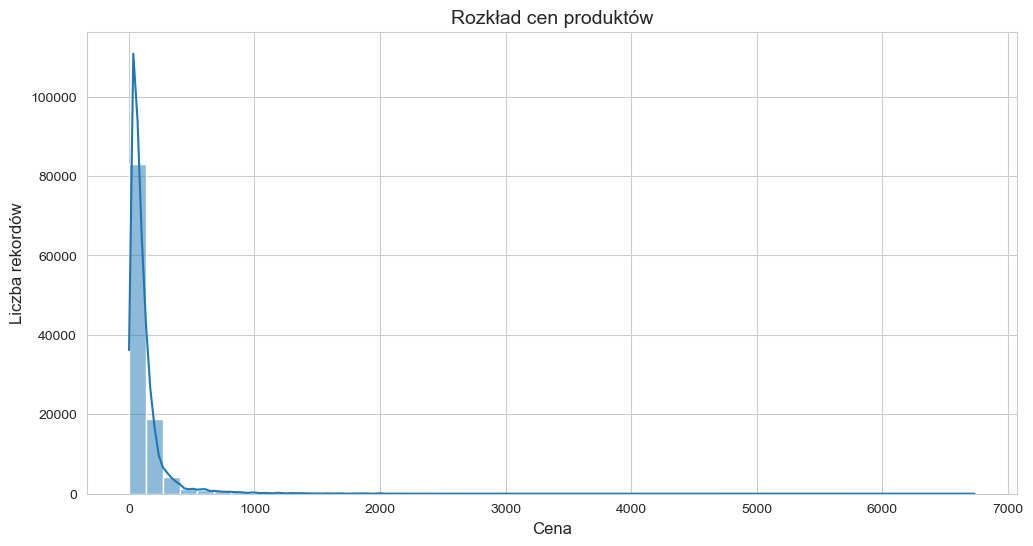

In [67]:
plt.figure(figsize=(12, 6))
sns.histplot(delivered_df["price"], bins=50, kde=True)

plt.title("Rozkład cen produktów")
plt.xlabel("Cena")
plt.ylabel("Liczba rekordów")
plt.show()

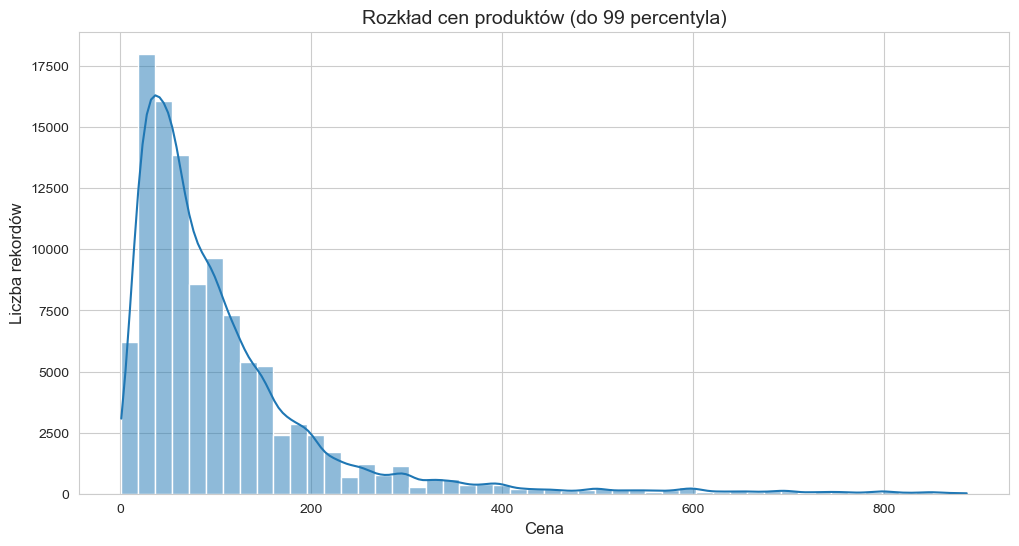

In [68]:
price_99 = delivered_df["price"].quantile(0.99)

filtered_price_df = delivered_df[delivered_df["price"] <= price_99]

plt.figure(figsize=(12, 6))
sns.histplot(filtered_price_df["price"], bins=50, kde=True)

plt.title("Rozkład cen produktów (do 99 percentyla)")
plt.xlabel("Cena")
plt.ylabel("Liczba rekordów")
plt.show()

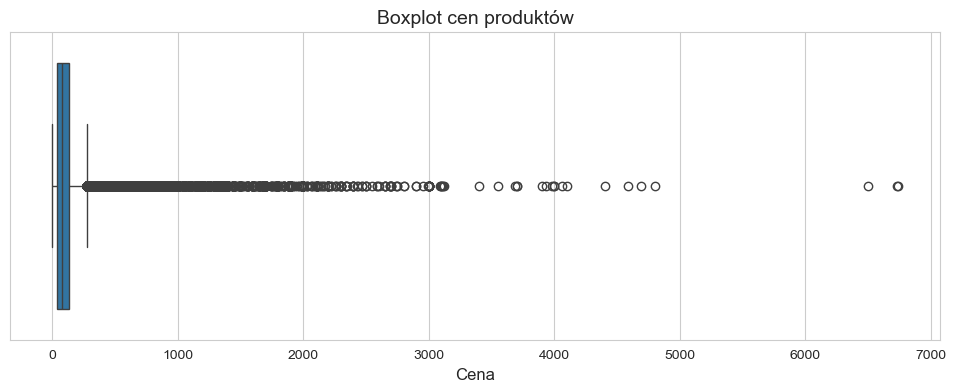

In [69]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=delivered_df["price"])

plt.title("Boxplot cen produktów")
plt.xlabel("Cena")
plt.show()

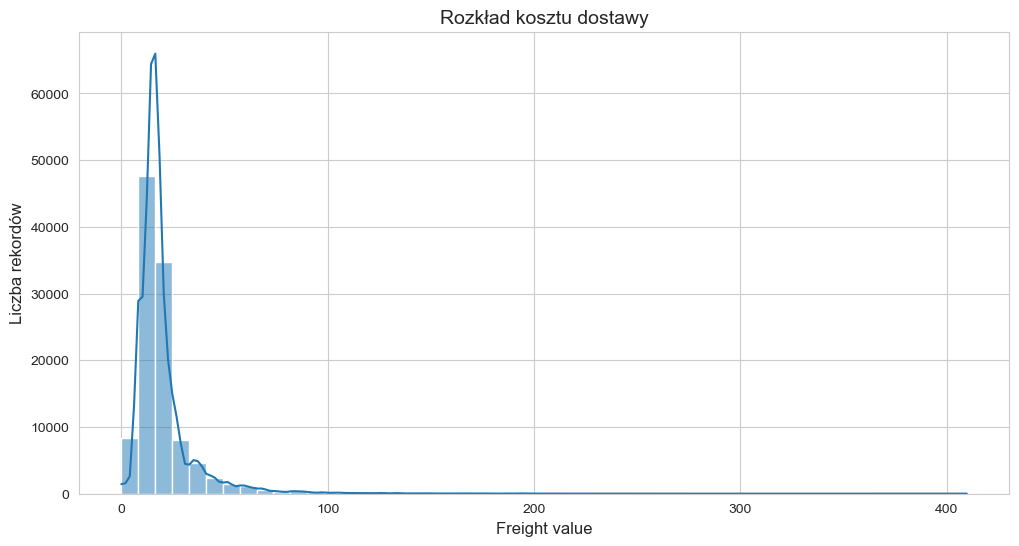

In [70]:
plt.figure(figsize=(12, 6))
sns.histplot(delivered_df["freight_value"], bins=50, kde=True)

plt.title("Rozkład kosztu dostawy")
plt.xlabel("Freight value")
plt.ylabel("Liczba rekordów")
plt.show()

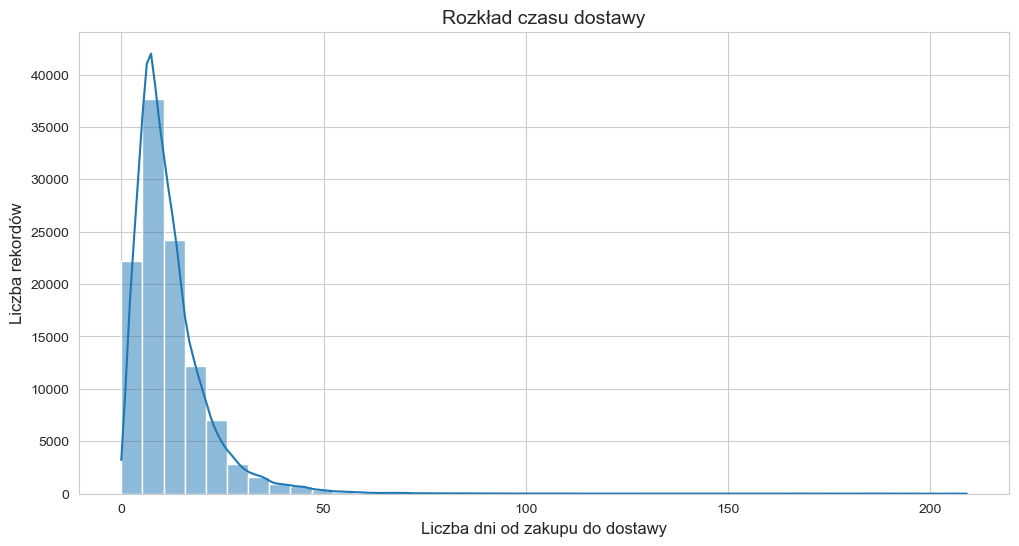

In [71]:
plt.figure(figsize=(12, 6))
sns.histplot(delivered_df["delivery_days"].dropna(), bins=40, kde=True)

plt.title("Rozkład czasu dostawy")
plt.xlabel("Liczba dni od zakupu do dostawy")
plt.ylabel("Liczba rekordów")
plt.show()

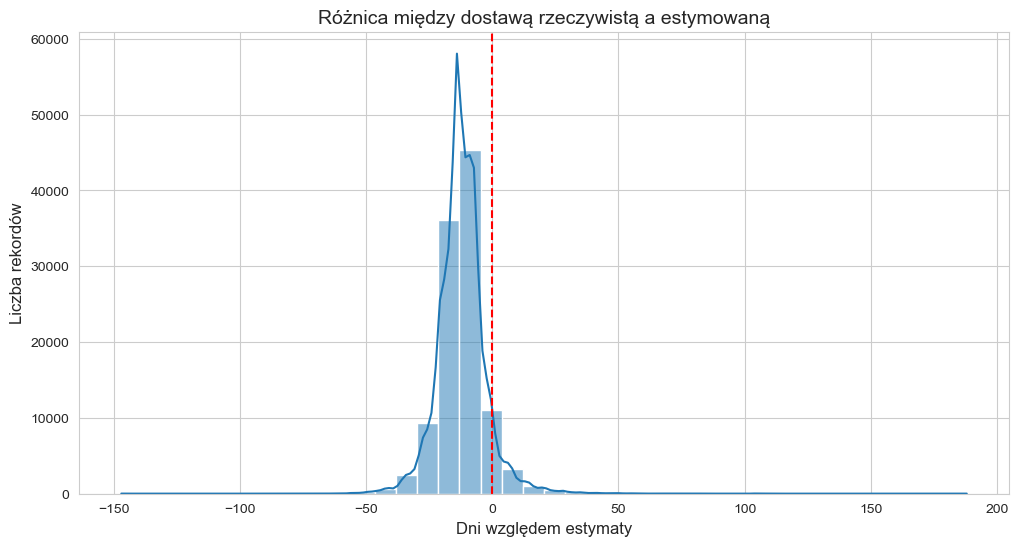

In [72]:
plt.figure(figsize=(12, 6))
sns.histplot(delivered_df["delivery_vs_estimate_days"].dropna(), bins=40, kde=True)

plt.title("Różnica między dostawą rzeczywistą a estymowaną")
plt.xlabel("Dni względem estymaty")
plt.ylabel("Liczba rekordów")
plt.axvline(0, color="red", linestyle="--")
plt.show()

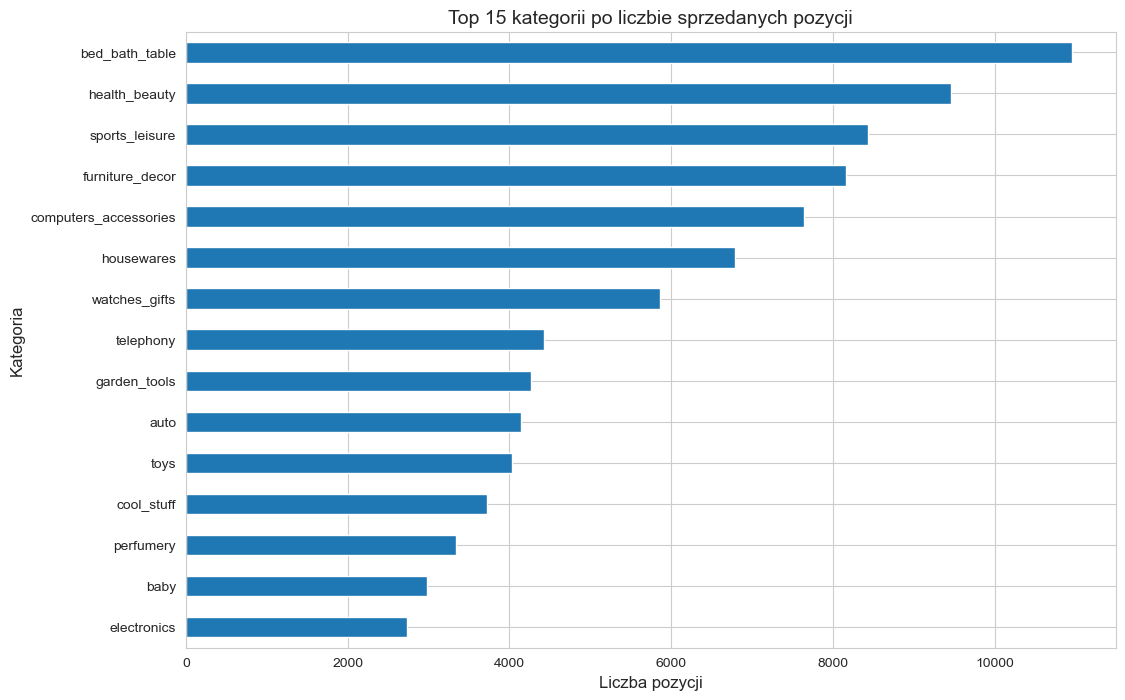

In [73]:
top_categories_count = (
    delivered_df["product_category_name_english"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 8))
top_categories_count.plot(kind="barh")

plt.title("Top 15 kategorii po liczbie sprzedanych pozycji")
plt.xlabel("Liczba pozycji")
plt.ylabel("Kategoria")
plt.show()

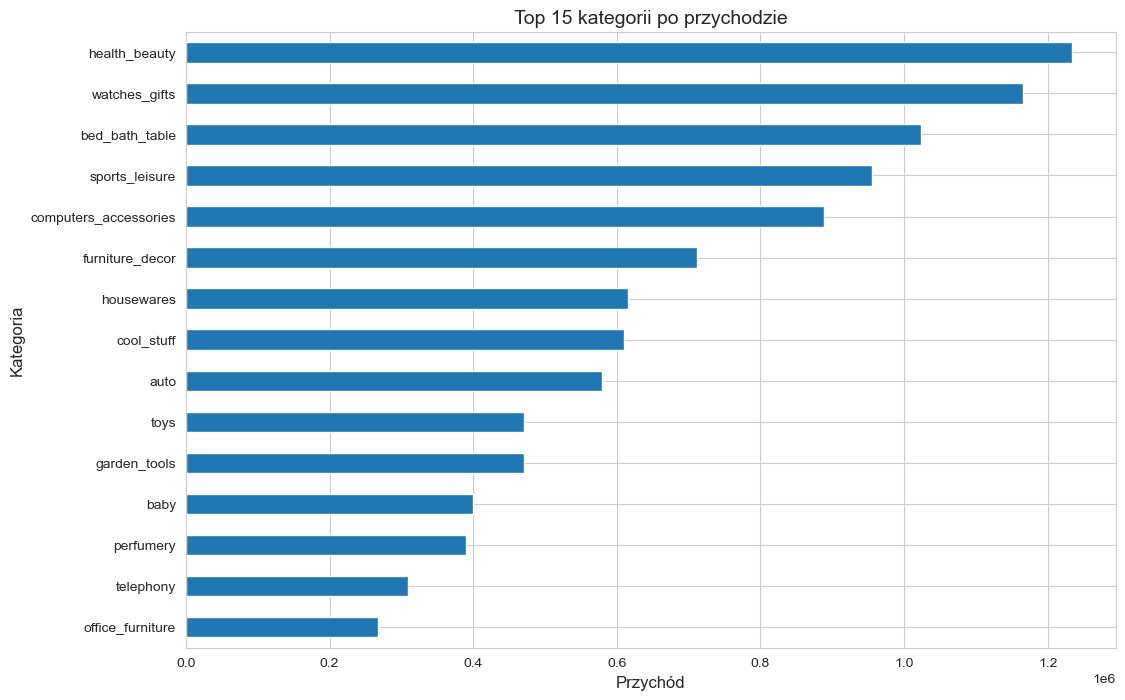

In [74]:
top_categories_revenue = (
    delivered_df.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 8))
top_categories_revenue.plot(kind="barh")

plt.title("Top 15 kategorii po przychodzie")
plt.xlabel("Przychód")
plt.ylabel("Kategoria")
plt.show()

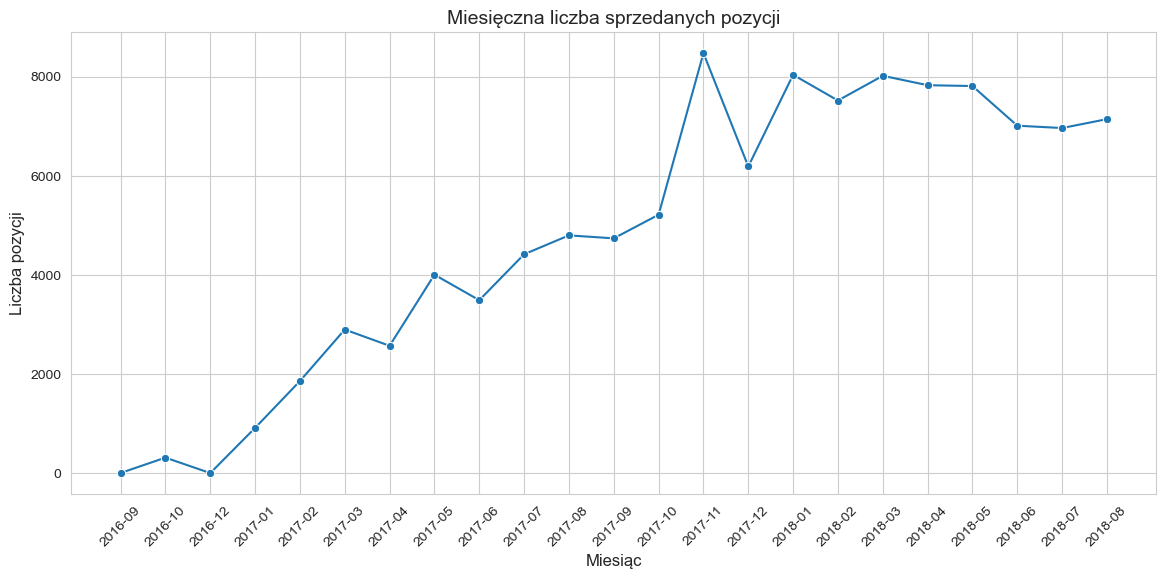

In [75]:
monthly_units = (
    delivered_df.groupby("purchase_month")
    .size()
    .reset_index(name="units_sold")
)

monthly_units["purchase_month"] = monthly_units["purchase_month"].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_units, x="purchase_month", y="units_sold", marker="o")

plt.title("Miesięczna liczba sprzedanych pozycji")
plt.xlabel("Miesiąc")
plt.ylabel("Liczba pozycji")
plt.xticks(rotation=45)
plt.show()

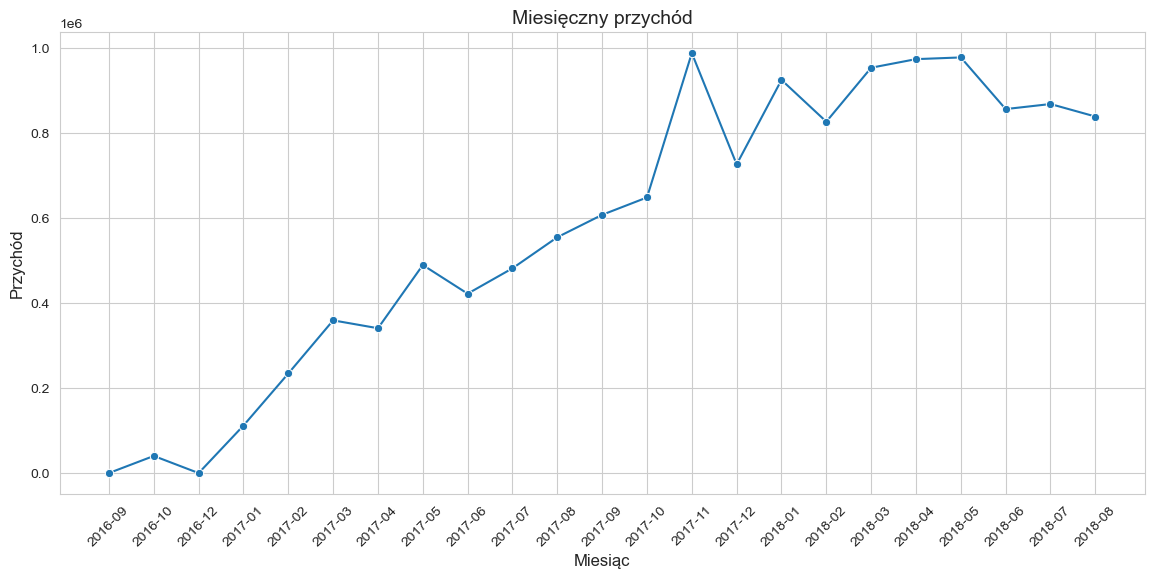

In [76]:
monthly_revenue = (
    delivered_df.groupby("purchase_month")["price"]
    .sum()
    .reset_index(name="revenue")
)

monthly_revenue["purchase_month"] = monthly_revenue["purchase_month"].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_revenue, x="purchase_month", y="revenue", marker="o")

plt.title("Miesięczny przychód")
plt.xlabel("Miesiąc")
plt.ylabel("Przychód")
plt.xticks(rotation=45)
plt.show()

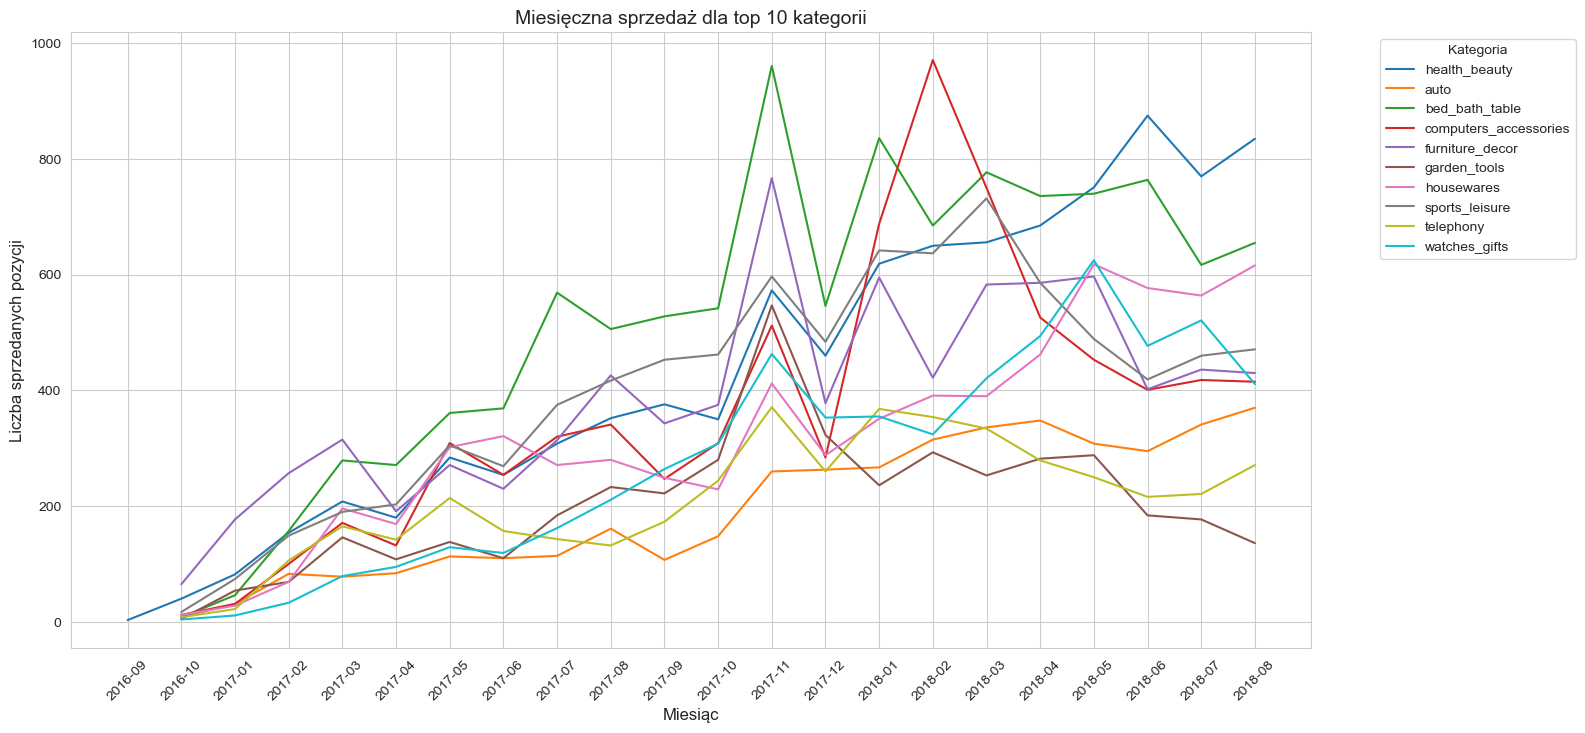

In [77]:
top_10_categories = (
    delivered_df["product_category_name_english"]
    .value_counts()
    .head(10)
    .index
)

monthly_top_categories = (
    delivered_df[delivered_df["product_category_name_english"].isin(top_10_categories)]
    .groupby(["purchase_month", "product_category_name_english"])
    .size()
    .reset_index(name="units_sold")
)

monthly_top_categories["purchase_month"] = monthly_top_categories["purchase_month"].astype(str)

plt.figure(figsize=(16, 8))
sns.lineplot(
    data=monthly_top_categories,
    x="purchase_month",
    y="units_sold",
    hue="product_category_name_english"
)

plt.title("Miesięczna sprzedaż dla top 10 kategorii")
plt.xlabel("Miesiąc")
plt.ylabel("Liczba sprzedanych pozycji")
plt.xticks(rotation=45)
plt.legend(title="Kategoria", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

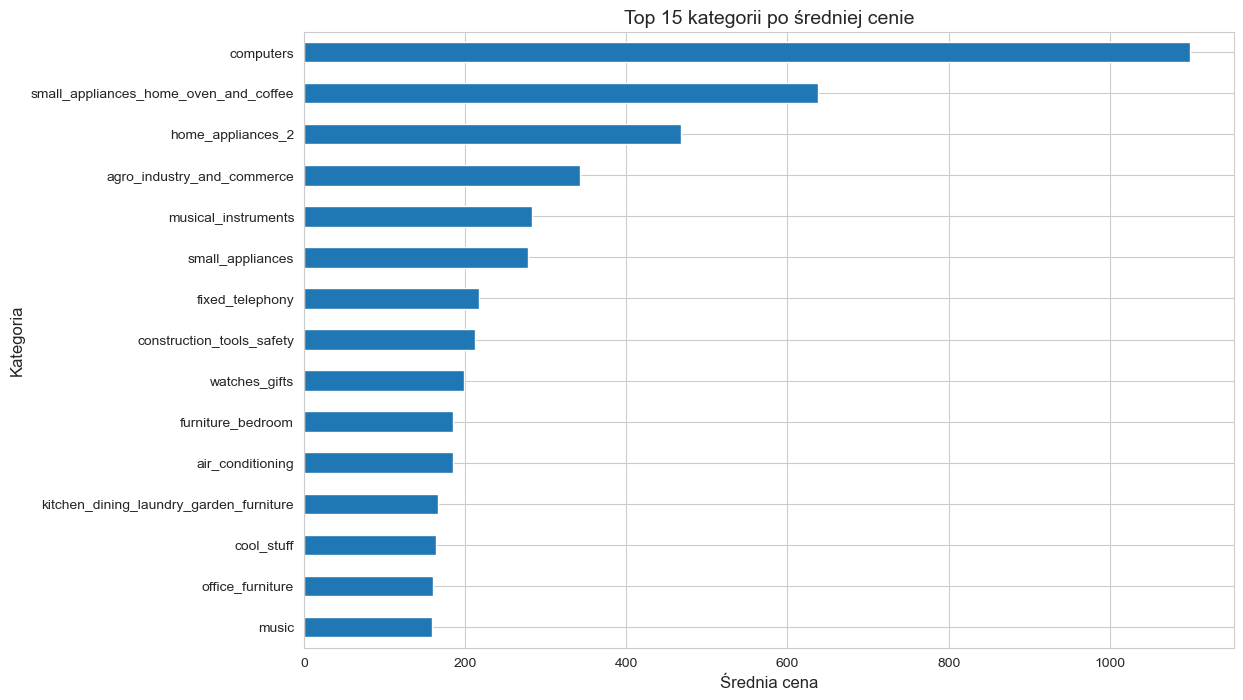

In [78]:
avg_price_top_categories = (
    delivered_df.groupby("product_category_name_english")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 8))
avg_price_top_categories.plot(kind="barh")

plt.title("Top 15 kategorii po średniej cenie")
plt.xlabel("Średnia cena")
plt.ylabel("Kategoria")
plt.show()

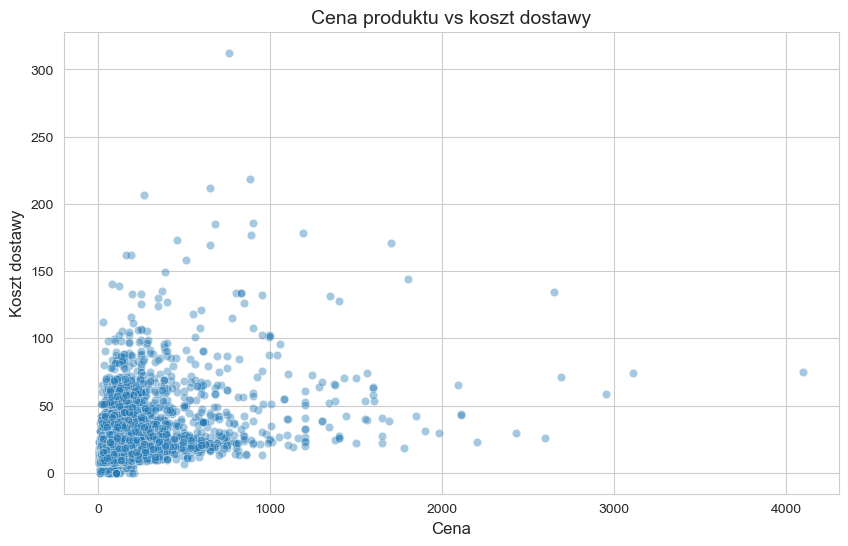

In [79]:
sample_df = delivered_df.sample(min(10000, len(delivered_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x="price", y="freight_value", alpha=0.4)

plt.title("Cena produktu vs koszt dostawy")
plt.xlabel("Cena")
plt.ylabel("Koszt dostawy")
plt.show()

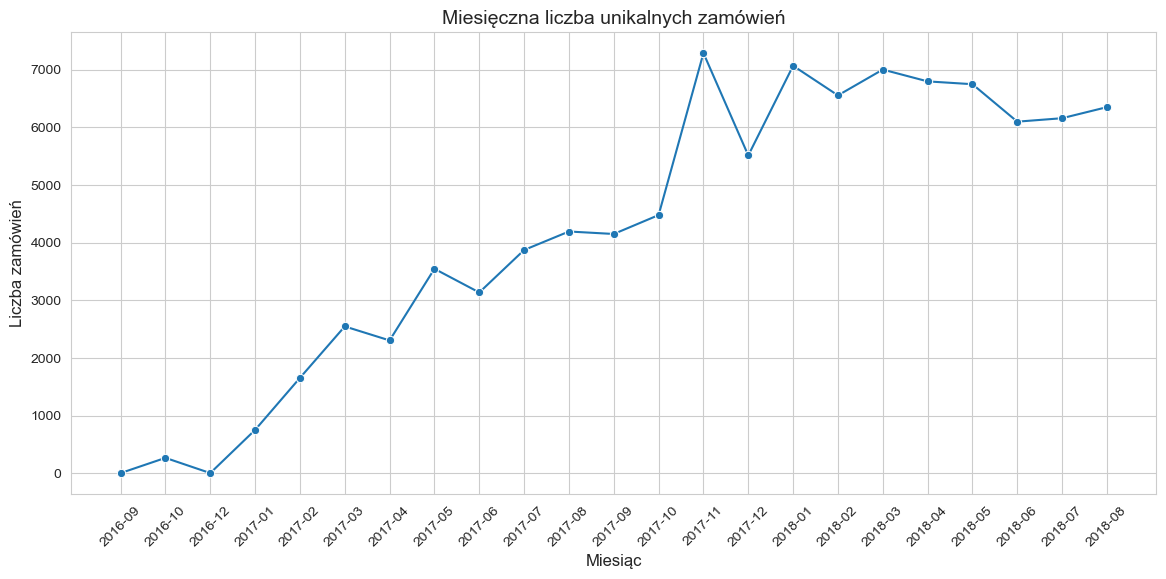

In [80]:
monthly_orders = (
    delivered_df.groupby("purchase_month")["order_id"]
    .nunique()
    .reset_index(name="unique_orders")
)

monthly_orders["purchase_month"] = monthly_orders["purchase_month"].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_orders, x="purchase_month", y="unique_orders", marker="o")

plt.title("Miesięczna liczba unikalnych zamówień")
plt.xlabel("Miesiąc")
plt.ylabel("Liczba zamówień")
plt.xticks(rotation=45)
plt.show()

In [81]:
total_orders = delivered_df["order_id"].nunique()
total_products_sold = len(delivered_df)
total_revenue = delivered_df["price"].sum()
avg_price = delivered_df["price"].mean()
avg_freight = delivered_df["freight_value"].mean()
avg_delivery_days = delivered_df["delivery_days"].mean()

print("Unikalne zamówienia:", total_orders)
print("Liczba sprzedanych pozycji:", total_products_sold)
print("Łączny przychód:", round(total_revenue, 2))
print("Średnia cena:", round(avg_price, 2))
print("Średni koszt dostawy:", round(avg_freight, 2))
print("Średni czas dostawy:", round(avg_delivery_days, 2))

Unikalne zamówienia: 96478
Liczba sprzedanych pozycji: 110197
Łączny przychód: 13221498.11
Średnia cena: 119.98
Średni koszt dostawy: 19.95
Średni czas dostawy: 12.01


Features Engineering 

In [82]:
ts_df = delivered_df[
    [
        "order_purchase_timestamp",
        "product_category_name_english",
        "order_id",
        "product_id",
        "price",
        "freight_value"
    ]
].copy()

ts_df.head()

,order_purchase_timestamp,product_category_name_english,order_id,product_id,price,freight_value
0,2017-09-13 08:59:02,cool_stuff,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29
1,2017-04-26 10:53:06,pet_shop,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93
2,2018-01-14 14:33:31,furniture_decor,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87
3,2018-08-08 10:00:35,perfumery,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,12.79
4,2017-02-04 13:57:51,garden_tools,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,18.14


In [83]:
ts_df = ts_df.dropna(subset=["product_category_name_english"]).copy()

print("Liczba rekordów po usunięciu braków kategorii:", len(ts_df))
print("Liczba unikalnych kategorii:", ts_df["product_category_name_english"].nunique())

Liczba rekordów po usunięciu braków kategorii: 108638
Liczba unikalnych kategorii: 71


In [84]:
ts_df["purchase_week_start"] = (
    ts_df["order_purchase_timestamp"]
    .dt.to_period("W")
    .apply(lambda r: r.start_time)
)

ts_df[["order_purchase_timestamp", "purchase_week_start"]].head()

,order_purchase_timestamp,purchase_week_start
0,2017-09-13 08:59:02,2017-09-11
1,2017-04-26 10:53:06,2017-04-24
2,2018-01-14 14:33:31,2018-01-08
3,2018-08-08 10:00:35,2018-08-06
4,2017-02-04 13:57:51,2017-01-30


In [85]:
weekly_df = (
    ts_df.groupby(["product_category_name_english", "purchase_week_start"])
    .agg(
        units_sold=("product_id", "count"),
        unique_orders=("order_id", "nunique"),
        revenue=("price", "sum"),
        avg_price=("price", "mean"),
        avg_freight=("freight_value", "mean")
    )
    .reset_index()
)

weekly_df.head()

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight
0,agro_industry_and_commerce,2017-01-23,2,1,43.98,21.990,8.720
1,agro_industry_and_commerce,2017-01-30,2,2,43.98,21.990,19.435
2,agro_industry_and_commerce,2017-02-06,2,2,114.89,57.445,19.375
3,agro_industry_and_commerce,2017-02-13,3,3,65.97,21.990,12.960
4,agro_industry_and_commerce,2017-02-20,1,1,21.99,21.990,14.110


In [86]:
print("Shape weekly_df:", weekly_df.shape)
print("Zakres czasu od:", weekly_df["purchase_week_start"].min())
print("Zakres czasu do:", weekly_df["purchase_week_start"].max())
print("Liczba kategorii:", weekly_df["product_category_name_english"].nunique())

weekly_df.sample(10, random_state=42)

Shape weekly_df: (4359, 7)
Zakres czasu od: 2016-09-12 00:00:00
Zakres czasu do: 2018-08-27 00:00:00
Liczba kategorii: 71


,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight
1509,electronics,2016-10-03,1,1,107.99,107.990000,11.800000
2232,furniture_decor,2017-01-16,68,54,4709.22,69.253235,15.576324
643,books_imported,2018-01-15,2,2,147.00,73.500000,14.260000
2346,furniture_living_room,2017-08-28,3,3,439.88,146.626667,23.313333
3917,sports_leisure,2017-10-16,110,99,12102.07,110.018818,17.546091
2460,garden_tools,2017-10-02,80,56,8286.96,103.587000,23.801625
1515,electronics,2017-02-27,11,7,431.90,39.263636,16.361818
3554,perfumery,2017-06-26,28,25,4134.19,147.649643,14.888214
2684,home_appliances_2,2017-05-22,1,1,89.99,89.990000,15.380000
1621,fashio_female_clothing,2018-08-20,2,1,94.98,47.490000,8.490000


In [87]:
all_categories = weekly_df["product_category_name_english"].unique()
all_weeks = pd.date_range(
    start=weekly_df["purchase_week_start"].min(),
    end=weekly_df["purchase_week_start"].max(),
    freq="W-MON"
)

full_index = pd.MultiIndex.from_product(
    [all_categories, all_weeks],
    names=["product_category_name_english", "purchase_week_start"]
)

weekly_full = (
    weekly_df.set_index(["product_category_name_english", "purchase_week_start"])
    .reindex(full_index)
    .reset_index()
)

weekly_full.head()

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight
0,agro_industry_and_commerce,2016-09-12,NaN,NaN,NaN,NaN,NaN
1,agro_industry_and_commerce,2016-09-19,NaN,NaN,NaN,NaN,NaN
2,agro_industry_and_commerce,2016-09-26,NaN,NaN,NaN,NaN,NaN
3,agro_industry_and_commerce,2016-10-03,NaN,NaN,NaN,NaN,NaN
4,agro_industry_and_commerce,2016-10-10,NaN,NaN,NaN,NaN,NaN


In [88]:
weekly_full["units_sold"] = weekly_full["units_sold"].fillna(0)
weekly_full["unique_orders"] = weekly_full["unique_orders"].fillna(0)
weekly_full["revenue"] = weekly_full["revenue"].fillna(0)

weekly_full["avg_price"] = weekly_full["avg_price"].fillna(0)
weekly_full["avg_freight"] = weekly_full["avg_freight"].fillna(0)

weekly_full.head(10)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0


In [89]:
weekly_full = weekly_full.sort_values(
    ["product_category_name_english", "purchase_week_start"]
).reset_index(drop=True)

weekly_full.head(10)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0


In [90]:
weekly_full["year"] = weekly_full["purchase_week_start"].dt.year
weekly_full["month"] = weekly_full["purchase_week_start"].dt.month
weekly_full["quarter"] = weekly_full["purchase_week_start"].dt.quarter
weekly_full["week_of_year"] = weekly_full["purchase_week_start"].dt.isocalendar().week.astype(int)

weekly_full.head()

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,week_of_year
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,37
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,38
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,39
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,40
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,41


In [91]:
weekly_full["is_month_start"] = weekly_full["purchase_week_start"].dt.is_month_start.astype(int)
weekly_full["is_month_end"] = weekly_full["purchase_week_start"].dt.is_month_end.astype(int)
weekly_full["is_quarter_start"] = weekly_full["purchase_week_start"].dt.is_quarter_start.astype(int)
weekly_full["is_quarter_end"] = weekly_full["purchase_week_start"].dt.is_quarter_end.astype(int)

weekly_full.head()

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,week_of_year,is_month_start,is_month_end,is_quarter_start,is_quarter_end
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,37,0,0,0,0
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,38,0,0,0,0
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,39,0,0,0,0
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,40,0,0,0,0
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,41,0,0,0,0


In [92]:
weekly_full["lag_1"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"].shift(1)
)

weekly_full["lag_2"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"].shift(2)
)

weekly_full["lag_4"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"].shift(4)
)

weekly_full["lag_8"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"].shift(8)
)

weekly_full.head(15)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,week_of_year,is_month_start,is_month_end,is_quarter_start,is_quarter_end,lag_1,lag_2,lag_4,lag_8
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,37,0,0,0,0,NaN,NaN,NaN,NaN
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,38,0,0,0,0,0.0,NaN,NaN,NaN
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,39,0,0,0,0,0.0,0.0,NaN,NaN
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,40,0,0,0,0,0.0,0.0,NaN,NaN
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,41,0,0,0,0,0.0,0.0,0.0,NaN
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0,2016,10,4,42,0,0,0,0,0.0,0.0,0.0,NaN
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0,2016,10,4,43,0,0,0,0,0.0,0.0,0.0,NaN
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0,2016,10,4,44,0,1,0,0,0.0,0.0,0.0,NaN
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,45,0,0,0,0,0.0,0.0,0.0,0.0
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,46,0,0,0,0,0.0,0.0,0.0,0.0


In [93]:
weekly_full["revenue_lag_1"] = (
    weekly_full.groupby("product_category_name_english")["revenue"].shift(1)
)

weekly_full["orders_lag_1"] = (
    weekly_full.groupby("product_category_name_english")["unique_orders"].shift(1)
)

weekly_full["avg_price_lag_1"] = (
    weekly_full.groupby("product_category_name_english")["avg_price"].shift(1)
)

weekly_full.head(15)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,...,is_month_end,is_quarter_start,is_quarter_end,lag_1,lag_2,lag_4,lag_8,revenue_lag_1,orders_lag_1,avg_price_lag_1
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0,0,0,0.0,NaN,NaN,NaN,0.0,0.0,0.0
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0,0,0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0,0,0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0,0,0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0,0,0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0,0,0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,1,0,0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [94]:
weekly_full["rolling_mean_4"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(window=4).mean())
)

weekly_full["rolling_std_4"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(window=4).std())
)

weekly_full["rolling_mean_8"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(window=8).mean())
)

weekly_full.head(15)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,...,lag_1,lag_2,lag_4,lag_8,revenue_lag_1,orders_lag_1,avg_price_lag_1,rolling_mean_4,rolling_std_4,rolling_mean_8
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0.0,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [95]:
weekly_full["revenue_roll_mean_4"] = (
    weekly_full.groupby("product_category_name_english")["revenue"]
    .transform(lambda x: x.shift(1).rolling(window=4).mean())
)

weekly_full["revenue_roll_std_4"] = (
    weekly_full.groupby("product_category_name_english")["revenue"]
    .transform(lambda x: x.shift(1).rolling(window=4).std())
)

weekly_full.head(15)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,...,lag_4,lag_8,revenue_lag_1,orders_lag_1,avg_price_lag_1,rolling_mean_4,rolling_std_4,rolling_mean_8,revenue_roll_mean_4,revenue_roll_std_4
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [96]:
weekly_full["momentum_1_4"] = weekly_full["lag_1"] - weekly_full["rolling_mean_4"]
weekly_full["momentum_1_8"] = weekly_full["lag_1"] - weekly_full["rolling_mean_8"]

weekly_full.head(15)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,...,revenue_lag_1,orders_lag_1,avg_price_lag_1,rolling_mean_4,rolling_std_4,rolling_mean_8,revenue_roll_mean_4,revenue_roll_std_4,momentum_1_4,momentum_1_8
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [97]:
weekly_full["units_pct_change_1"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"]
    .transform(lambda x: x.shift(1).pct_change())
)

weekly_full["revenue_pct_change_1"] = (
    weekly_full.groupby("product_category_name_english")["revenue"]
    .transform(lambda x: x.shift(1).pct_change())
)

weekly_full.head(15)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,...,avg_price_lag_1,rolling_mean_4,rolling_std_4,rolling_mean_8,revenue_roll_mean_4,revenue_roll_std_4,momentum_1_4,momentum_1_8,units_pct_change_1,revenue_pct_change_1
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [98]:
weekly_full.isnull().sum().sort_values(ascending=False).head(20)

revenue_pct_change_1    2507
units_pct_change_1      2507
momentum_1_8             568
rolling_mean_8           568
lag_8                    568
momentum_1_4             284
revenue_roll_std_4       284
revenue_roll_mean_4      284
rolling_std_4            284
rolling_mean_4           284
lag_4                    284
lag_2                    142
avg_price_lag_1           71
orders_lag_1              71
revenue_lag_1             71
lag_1                     71
purchase_week_start        0
is_quarter_end             0
is_quarter_start           0
is_month_end               0
dtype: int64

In [99]:
weekly_full = weekly_full.replace([np.inf, -np.inf], np.nan)

In [100]:
feature_df = weekly_full.dropna(
    subset=[
        "lag_1",
        "lag_2",
        "lag_4",
        "rolling_mean_4",
        "rolling_mean_8"
    ]
).copy()

print("weekly_full shape:", weekly_full.shape)
print("feature_df shape:", feature_df.shape)

weekly_full shape: (7313, 31)
feature_df shape: (6745, 31)


In [101]:
model_df = feature_df[
    [
        "product_category_name_english",
        "purchase_week_start",
        "units_sold",
        "unique_orders",
        "revenue",
        "avg_price",
        "avg_freight",
        "year",
        "month",
        "quarter",
        "week_of_year",
        "is_month_start",
        "is_month_end",
        "is_quarter_start",
        "is_quarter_end",
        "lag_1",
        "lag_2",
        "lag_4",
        "lag_8",
        "revenue_lag_1",
        "orders_lag_1",
        "avg_price_lag_1",
        "rolling_mean_4",
        "rolling_std_4",
        "rolling_mean_8",
        "revenue_roll_mean_4",
        "revenue_roll_std_4",
        "momentum_1_4",
        "momentum_1_8",
        "units_pct_change_1",
        "revenue_pct_change_1"
    ]
].copy()

model_df.head()

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,...,avg_price_lag_1,rolling_mean_4,rolling_std_4,rolling_mean_8,revenue_roll_mean_4,revenue_roll_std_4,momentum_1_4,momentum_1_8,units_pct_change_1,revenue_pct_change_1
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
10,agro_industry_and_commerce,2016-11-21,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
11,agro_industry_and_commerce,2016-11-28,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
12,agro_industry_and_commerce,2016-12-05,0.0,0.0,0.0,0.0,0.0,2016,12,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [102]:
print("Shape model_df:", model_df.shape)
print("Nulls w model_df:")
print(model_df.isnull().sum().sort_values(ascending=False).head(20))

print("\nLiczba kategorii:", model_df["product_category_name_english"].nunique())
print("Pierwsza data:", model_df["purchase_week_start"].min())
print("Ostatnia data:", model_df["purchase_week_start"].max())

Shape model_df: (6745, 31)
Nulls w model_df:
revenue_pct_change_1             2517
units_pct_change_1               2517
lag_2                               0
momentum_1_8                        0
momentum_1_4                        0
revenue_roll_std_4                  0
revenue_roll_mean_4                 0
rolling_mean_8                      0
rolling_std_4                       0
rolling_mean_4                      0
avg_price_lag_1                     0
orders_lag_1                        0
revenue_lag_1                       0
lag_8                               0
lag_4                               0
product_category_name_english       0
purchase_week_start                 0
is_quarter_end                      0
is_quarter_start                    0
is_month_end                        0
dtype: int64

Liczba kategorii: 71
Pierwsza data: 2016-11-07 00:00:00
Ostatnia data: 2018-08-27 00:00:00


In [103]:
model_df.to_csv("dane/model_weekly_features.csv", index=False)

Przygotowanie do modelowa 

In [104]:
print("Shape model_df:", model_df.shape)
print("\nKolumny:")
print(model_df.columns.tolist())

print("\nPróba danych:")
display(model_df.head())

print("\nZakres czasu:")
print("Od:", model_df["purchase_week_start"].min())
print("Do:", model_df["purchase_week_start"].max())

print("\nLiczba kategorii:")
print(model_df["product_category_name_english"].nunique())

Shape model_df: (6745, 31)

Kolumny:
['product_category_name_english', 'purchase_week_start', 'units_sold', 'unique_orders', 'revenue', 'avg_price', 'avg_freight', 'year', 'month', 'quarter', 'week_of_year', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'revenue_lag_1', 'orders_lag_1', 'avg_price_lag_1', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'revenue_roll_mean_4', 'revenue_roll_std_4', 'momentum_1_4', 'momentum_1_8', 'units_pct_change_1', 'revenue_pct_change_1']

Próba danych:


,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,...,avg_price_lag_1,rolling_mean_4,rolling_std_4,rolling_mean_8,revenue_roll_mean_4,revenue_roll_std_4,momentum_1_4,momentum_1_8,units_pct_change_1,revenue_pct_change_1
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
10,agro_industry_and_commerce,2016-11-21,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
11,agro_industry_and_commerce,2016-11-28,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
12,agro_industry_and_commerce,2016-12-05,0.0,0.0,0.0,0.0,0.0,2016,12,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN



Zakres czasu:
Od: 2016-11-07 00:00:00
Do: 2018-08-27 00:00:00

Liczba kategorii:
71


In [105]:
print("Braki danych:")
print(model_df.isnull().sum().sort_values(ascending=False).head(20))

print("\nTypy danych:")
print(model_df.dtypes)

Braki danych:
revenue_pct_change_1             2517
units_pct_change_1               2517
lag_2                               0
momentum_1_8                        0
momentum_1_4                        0
revenue_roll_std_4                  0
revenue_roll_mean_4                 0
rolling_mean_8                      0
rolling_std_4                       0
rolling_mean_4                      0
avg_price_lag_1                     0
orders_lag_1                        0
revenue_lag_1                       0
lag_8                               0
lag_4                               0
product_category_name_english       0
purchase_week_start                 0
is_quarter_end                      0
is_quarter_start                    0
is_month_end                        0
dtype: int64

Typy danych:
product_category_name_english            object
purchase_week_start              datetime64[ns]
units_sold                              float64
unique_orders                           float64
revenue

In [106]:
target = "units_sold"

In [107]:
drop_columns = [
    "units_sold",                       # target
    "purchase_week_start"              # data jako znacznik czasu, nie surowa liczba
]

In [108]:
feature_columns = [col for col in model_df.columns if col not in drop_columns]

print("Liczba feature'ów:", len(feature_columns))
print(feature_columns)

Liczba feature'ów: 29
['product_category_name_english', 'unique_orders', 'revenue', 'avg_price', 'avg_freight', 'year', 'month', 'quarter', 'week_of_year', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'revenue_lag_1', 'orders_lag_1', 'avg_price_lag_1', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'revenue_roll_mean_4', 'revenue_roll_std_4', 'momentum_1_4', 'momentum_1_8', 'units_pct_change_1', 'revenue_pct_change_1']


In [109]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

model_df["category_encoded"] = le.fit_transform(model_df["product_category_name_english"])

display(
    model_df[
        ["product_category_name_english", "category_encoded"]
    ].drop_duplicates().head(10)
)

,product_category_name_english,category_encoded
8,agro_industry_and_commerce,0
111,air_conditioning,1
214,art,2
317,arts_and_craftmanship,3
420,audio,4
523,auto,5
626,baby,6
729,bed_bath_table,7
832,books_general_interest,8
935,books_imported,9


In [110]:
drop_columns = [
    "units_sold",
    "purchase_week_start",
    "product_category_name_english"
]

feature_columns = [col for col in model_df.columns if col not in drop_columns]

print("Feature columns:")
print(feature_columns)

Feature columns:
['unique_orders', 'revenue', 'avg_price', 'avg_freight', 'year', 'month', 'quarter', 'week_of_year', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'revenue_lag_1', 'orders_lag_1', 'avg_price_lag_1', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'revenue_roll_mean_4', 'revenue_roll_std_4', 'momentum_1_4', 'momentum_1_8', 'units_pct_change_1', 'revenue_pct_change_1', 'category_encoded']


In [111]:
sorted_dates = sorted(model_df["purchase_week_start"].unique())

print("Liczba unikalnych tygodni:", len(sorted_dates))
print("Pierwsze 5 tygodni:", sorted_dates[:5])
print("Ostatnie 5 tygodni:", sorted_dates[-5:])

Liczba unikalnych tygodni: 95
Pierwsze 5 tygodni: [Timestamp('2016-11-07 00:00:00'), Timestamp('2016-11-14 00:00:00'), Timestamp('2016-11-21 00:00:00'), Timestamp('2016-11-28 00:00:00'), Timestamp('2016-12-05 00:00:00')]
Ostatnie 5 tygodni: [Timestamp('2018-07-30 00:00:00'), Timestamp('2018-08-06 00:00:00'), Timestamp('2018-08-13 00:00:00'), Timestamp('2018-08-20 00:00:00'), Timestamp('2018-08-27 00:00:00')]


In [112]:
n_dates = len(sorted_dates)

train_end_idx = int(n_dates * 0.70)
valid_end_idx = int(n_dates * 0.85)

train_end_date = sorted_dates[train_end_idx - 1]
valid_end_date = sorted_dates[valid_end_idx - 1]

print("Train end date:", train_end_date)
print("Validation end date:", valid_end_date)
print("Test end date:", sorted_dates[-1])

Train end date: 2018-02-05 00:00:00
Validation end date: 2018-05-14 00:00:00
Test end date: 2018-08-27 00:00:00


In [113]:
train_df = model_df[model_df["purchase_week_start"] <= train_end_date].copy()

valid_df = model_df[
    (model_df["purchase_week_start"] > train_end_date) &
    (model_df["purchase_week_start"] <= valid_end_date)
].copy()

test_df = model_df[model_df["purchase_week_start"] > valid_end_date].copy()

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape:", test_df.shape)

Train shape: (4686, 32)
Valid shape: (994, 32)
Test shape: (1065, 32)


In [114]:
print("TRAIN:")
print(train_df["purchase_week_start"].min(), "->", train_df["purchase_week_start"].max())

print("\nVALID:")
print(valid_df["purchase_week_start"].min(), "->", valid_df["purchase_week_start"].max())

print("\nTEST:")
print(test_df["purchase_week_start"].min(), "->", test_df["purchase_week_start"].max())

TRAIN:
2016-11-07 00:00:00 -> 2018-02-05 00:00:00

VALID:
2018-02-12 00:00:00 -> 2018-05-14 00:00:00

TEST:
2018-05-21 00:00:00 -> 2018-08-27 00:00:00


In [115]:
X_train = train_df[feature_columns].copy()
y_train = train_df[target].copy()

X_valid = valid_df[feature_columns].copy()
y_valid = valid_df[target].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (4686, 29)
y_train: (4686,)
X_valid: (994, 29)
y_valid: (994,)
X_test: (1065, 29)
y_test: (1065,)


In [116]:
display(X_train.head())

,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,week_of_year,is_month_start,is_month_end,...,rolling_mean_4,rolling_std_4,rolling_mean_8,revenue_roll_mean_4,revenue_roll_std_4,momentum_1_4,momentum_1_8,units_pct_change_1,revenue_pct_change_1,category_encoded
8,0.0,0.0,0.0,0.0,2016,11,4,45,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0
9,0.0,0.0,0.0,0.0,2016,11,4,46,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0
10,0.0,0.0,0.0,0.0,2016,11,4,47,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0
11,0.0,0.0,0.0,0.0,2016,11,4,48,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0
12,0.0,0.0,0.0,0.0,2016,12,4,49,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0


In [117]:
print(X_train.dtypes.value_counts())
print("\nPełne typy:")
print(X_train.dtypes)

float64    20
int64       6
int32       3
Name: count, dtype: int64

Pełne typy:
unique_orders           float64
revenue                 float64
avg_price               float64
avg_freight             float64
year                      int32
month                     int32
quarter                   int32
week_of_year              int64
is_month_start            int64
is_month_end              int64
is_quarter_start          int64
is_quarter_end            int64
lag_1                   float64
lag_2                   float64
lag_4                   float64
lag_8                   float64
revenue_lag_1           float64
orders_lag_1            float64
avg_price_lag_1         float64
rolling_mean_4          float64
rolling_std_4           float64
rolling_mean_8          float64
revenue_roll_mean_4     float64
revenue_roll_std_4      float64
momentum_1_4            float64
momentum_1_8            float64
units_pct_change_1      float64
revenue_pct_change_1    float64
category_encoded       

In [118]:
print("NaN w X_train:", X_train.isnull().sum().sum())
print("NaN w X_valid:", X_valid.isnull().sum().sum())
print("NaN w X_test:", X_test.isnull().sum().sum())

print("NaN w y_train:", y_train.isnull().sum())
print("NaN w y_valid:", y_valid.isnull().sum())
print("NaN w y_test:", y_test.isnull().sum())

NaN w X_train: 4216
NaN w X_valid: 380
NaN w X_test: 438
NaN w y_train: 0
NaN w y_valid: 0
NaN w y_test: 0


In [119]:
baseline_pred_valid = X_valid["lag_1"]
baseline_pred_test = X_test["lag_1"]

display(baseline_pred_valid.head())

74    8.0
75    3.0
76    4.0
77    9.0
78    5.0
Name: lag_1, dtype: float64

In [120]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [121]:
baseline_valid_rmse = rmse(y_valid, baseline_pred_valid)
baseline_valid_mae = mean_absolute_error(y_valid, baseline_pred_valid)
baseline_valid_mape = mape(y_valid, baseline_pred_valid)

baseline_test_rmse = rmse(y_test, baseline_pred_test)
baseline_test_mae = mean_absolute_error(y_test, baseline_pred_test)
baseline_test_mape = mape(y_test, baseline_pred_test)

print("BASELINE - VALID")
print("RMSE:", round(baseline_valid_rmse, 4))
print("MAE:", round(baseline_valid_mae, 4))
print("MAPE:", round(baseline_valid_mape, 2), "%")

print("\nBASELINE - TEST")
print("RMSE:", round(baseline_test_rmse, 4))
print("MAE:", round(baseline_test_mae, 4))
print("MAPE:", round(baseline_test_mape, 2), "%")

BASELINE - VALID
RMSE: 11.9533
MAE: 5.9306
MAPE: 53.8 %

BASELINE - TEST
RMSE: 16.9809
MAE: 8.0798
MAPE: 102.48 %


In [122]:
train_df.to_csv("dane/train_weekly.csv", index=False)
valid_df.to_csv("dane/valid_weekly.csv", index=False)
test_df.to_csv("dane/test_weekly.csv", index=False)

In [123]:
with open("dane/feature_columns.txt", "w", encoding="utf-8") as f:
    for col in feature_columns:
        f.write(col + "\n")

In [124]:
# =====================================================
# PODSUMOWANIE DANYCH I CECH
# =====================================================

print("=" * 60)
print("PODSUMOWANIE DATASETU DO MODELU")
print("=" * 60)

# 1. Liczba wierszy (obserwacji)
print(f"Liczba wierszy (obserwacji): {model_df.shape[0]:,}")

# 2. Liczba unikalnych tygodni
print(f"Liczba unikalnych tygodni: {model_df['purchase_week_start'].nunique():,}")

# 3. Zakres czasu
print(f"Pierwszy tydzień: {model_df['purchase_week_start'].min()}")
print(f"Ostatni tydzień: {model_df['purchase_week_start'].max()}")
print(f"Całkowity zakres: {len(model_df['purchase_week_start'].unique())} tygodni")

# 4. Liczba kategorii
print(f"Liczba kategorii produktów: {model_df['product_category_name_english'].nunique():,}")

# 5. Liczba cech (feature columns)
print(f"Liczba cech (features): {len(feature_columns)}")
print("\nLista cech:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {col}")

# 6. Typy cech
numeric_features = feature_columns
feature_types = model_df[feature_columns].dtypes.value_counts()
print(f"\nTypy cech:")
for dtype, count in feature_types.items():
    print(f"  {dtype}: {count} cech")

# 7. Braki w cechach
null_counts = model_df[feature_columns].isnull().sum()
null_summary = null_counts[null_counts > 0]
if len(null_summary) > 0:
    print(f"\nBraki w cechach (suma): {null_counts.sum():,}")
    print("Cechy z brakami:")
    for col, nulls in null_summary.items():
        print(f"  {col}: {nulls:,} ({nulls/len(model_df)*100:.1f}%)")
else:
    print("\nBraki w cechach: 0")

# 8. Podstawowe statystyki targetu
print(f"\nTarget '{target}':")
print(f"  Min: {model_df[target].min():.2f}")
print(f"  Max: {model_df[target].max():.2f}")
print(f"  Średnia: {model_df[target].mean():.2f}")
print(f"  Mediana: {model_df[target].median():.2f}")
print(f"  Zeros: {len(model_df[model_df[target] == 0]):,} ({len(model_df[model_df[target] == 0])/len(model_df)*100:.1f}%)")

# 9. Podział na train/valid/test
print(f"\nPodział danych:")
print(f"  Train: {X_train.shape[0]:,} wierszy ({X_train.shape[0]/model_df.shape[0]*100:.1f}%)")
print(f"  Valid: {X_valid.shape[0]:,} wierszy ({X_valid.shape[0]/model_df.shape[0]*100:.1f}%)")
print(f"  Test:  {X_test.shape[0]:,} wierszy ({X_test.shape[0]/model_df.shape[0]*100:.1f}%)")

# 10. Baseline metryki (jeśli masz)
if 'baseline_valid_rmse' in locals():
    print(f"\nBaseline VALID:")
    print(f"  RMSE: {baseline_valid_rmse:.4f}")
    print(f"  MAE:  {baseline_valid_mae:.4f}")
    print(f"  MAPE: {baseline_valid_mape:.2f}%")

print("\n" + "=" * 60)
print("GOTOWY DO TRENINGU MODELU!")
print("=" * 60)

PODSUMOWANIE DATASETU DO MODELU
Liczba wierszy (obserwacji): 6,745
Liczba unikalnych tygodni: 95
Pierwszy tydzień: 2016-11-07 00:00:00
Ostatni tydzień: 2018-08-27 00:00:00
Całkowity zakres: 95 tygodni
Liczba kategorii produktów: 71
Liczba cech (features): 29

Lista cech:
   1. unique_orders
   2. revenue
   3. avg_price
   4. avg_freight
   5. year
   6. month
   7. quarter
   8. week_of_year
   9. is_month_start
  10. is_month_end
  11. is_quarter_start
  12. is_quarter_end
  13. lag_1
  14. lag_2
  15. lag_4
  16. lag_8
  17. revenue_lag_1
  18. orders_lag_1
  19. avg_price_lag_1
  20. rolling_mean_4
  21. rolling_std_4
  22. rolling_mean_8
  23. revenue_roll_mean_4
  24. revenue_roll_std_4
  25. momentum_1_4
  26. momentum_1_8
  27. units_pct_change_1
  28. revenue_pct_change_1
  29. category_encoded

Typy cech:
  float64: 20 cech
  int64: 6 cech
  int32: 3 cech

Braki w cechach (suma): 5,034
Cechy z brakami:
  units_pct_change_1: 2,517 (37.3%)
  revenue_pct_change_1: 2,517 (37.3%)


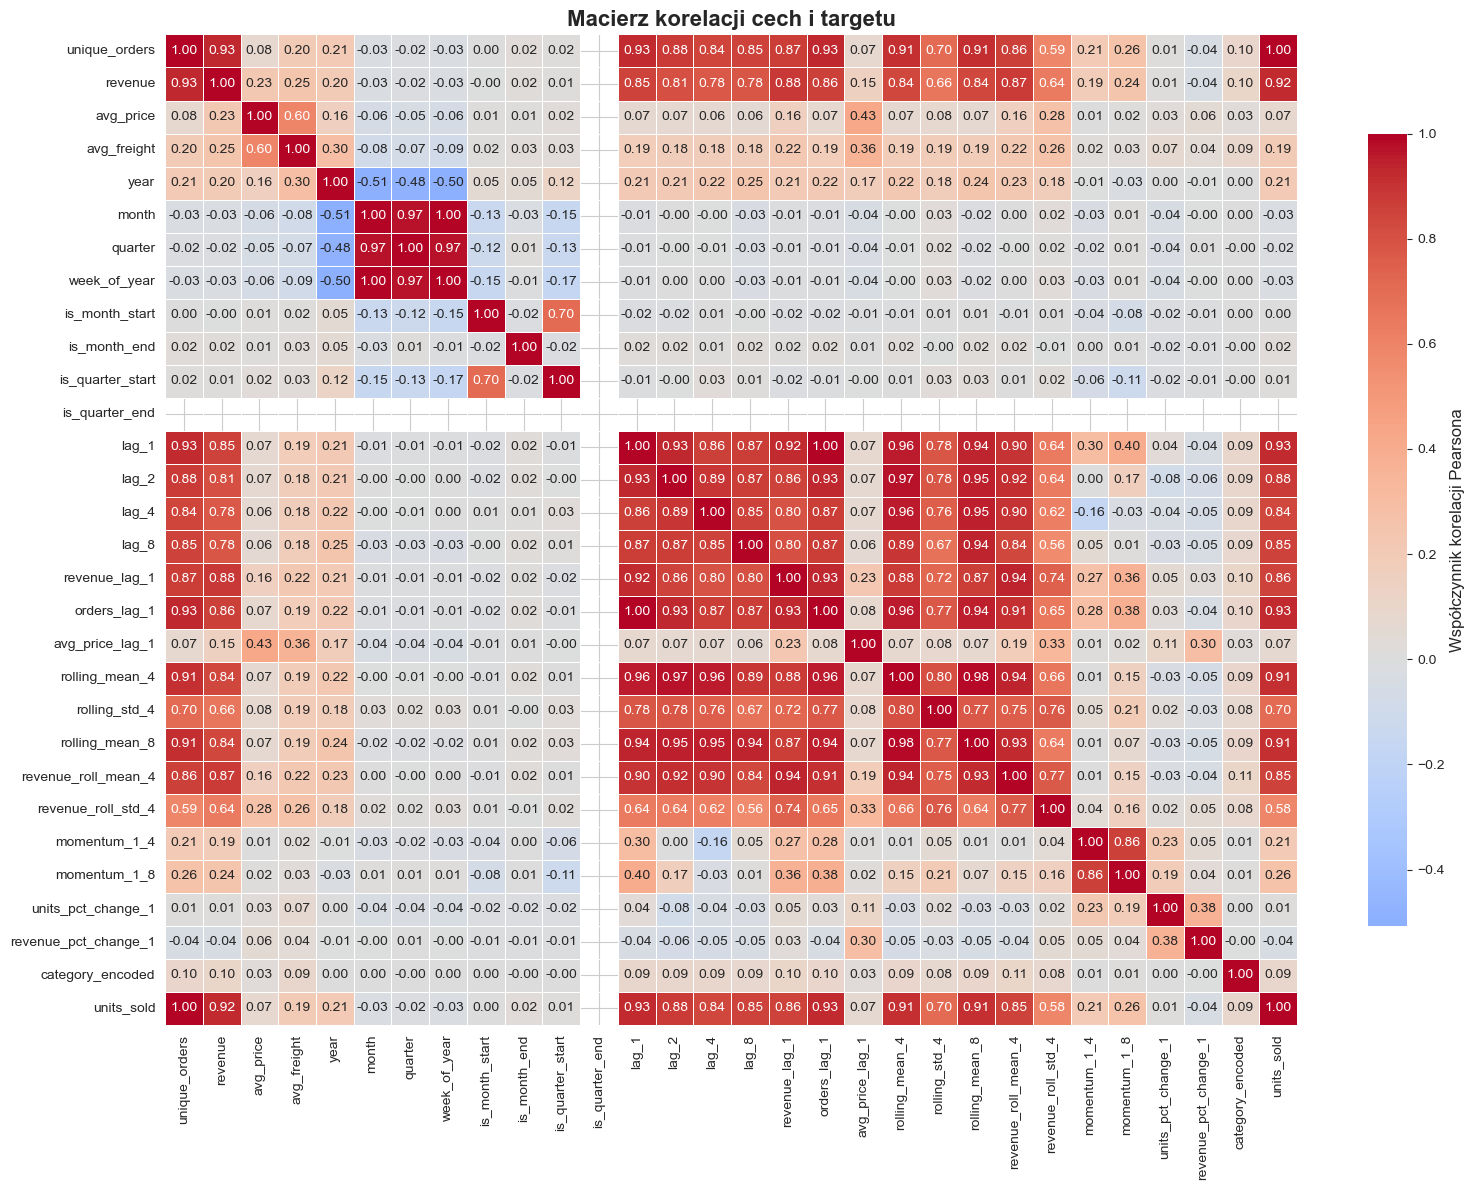

In [135]:
# 1️⃣ Ustawienie rozmiaru wykresu
plt.figure(figsize=(16, 12))  # rozmiar w calach – wystarczająco duży, by wszystko było czytelne

# 2️⃣ Obliczenie macierzy korelacji tylko dla wybranych kolumn (features + target)
corr_matrix = model_df[feature_columns + [target]].corr()

# 3️⃣ Tworzenie wykresu korelacji (heatmapy)
sns.heatmap(
    corr_matrix,
    annot=True,       # pokazuje wartości numeryczne na kaflach
    fmt=".2f",        # dwie liczby po przecinku dla czytelności
    cmap="coolwarm",  # paleta kolorów z kontrastem – przejrzysta wizualnie
    center=0,         # punkt odniesienia – środek skali kolorów
    linewidths=0.5,   # cienkie linie oddzielające kafle
    cbar_kws={"shrink": 0.8, "label": "Współczynnik korelacji Pearsona"}  # opis legendy
)

# 4️⃣ Tytuł wykresu
plt.title("Macierz korelacji cech i targetu", fontsize=16, fontweight="bold")
plt.tight_layout()  # automatyczne dopasowanie rozmieszczenia elementów
plt.show()